In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- IMPORTING FROM OTHER FILES
import sys
import os

# Add path to the package: relativistic_dof
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from relativistic_dof import RelativisticDOFRegistry
from axion_model_analysis import AxionModelDistribution
from second_interpolation import get_process

## Configure the Setup and Select the Production Channel

In this section, we choose the axion production process to analyze and set flags that control output behavior (e.g., saving plots or data). Additional parameters:

- `file_number`: We define it, to select the process:
  - $0$ : Electron scattering
  - $1$ : Muon decay
  - $2$ : Muon scattering
  - $3$ : Tau decay
  - $4$ : Tau scattering

In [3]:
# --- SELECT FILE, SET FLAGS (MANUAL) ---
file_number = 4
index_main = 100   # index of the distribution

In [4]:
# --- Define process labels and corresponding filenames for selected production channel ---
title_arr = [
    r"$\bf e$ scattering",
    r"$\bf \mu$ decay", 
    r"$\bf \mu$ scattering",
    r"$\bf \tau$ decay", 
    r"$\bf \tau$ scattering"
]
filename_dist_arr = [
    "Distributions_fa_e_scat.dat", 
    "Distributions_fa_mu_dec.dat", 
    "Distributions_fa_mu_scat.dat",
    "Distributions_fa_tau_dec_extended.dat", #"Distributions_fa_tau_dec.dat" 
    "Distributions_fa_tau_scat_extended.dat", #"Distributions_fa_tau_scat.dat"
]
proces_name_arr = [
    "electron_scattering", 
    "muon_decay", 
    "muon_scattering", 
    "tau_decay", 
    "tau_scattering"
]

# --- Define particle masses [in eV] ---
electron_mass = 0.511e6      # [eV]
muon_mass = 105.66e6         # [eV]
tau_mass = 1777e6            # [eV]
particle_mass_arr = [electron_mass, muon_mass, muon_mass, tau_mass, tau_mass]
####################################################################################################################
filename_dist = f"../../data-new/{filename_dist_arr[file_number]}"
# filename_dist = f"/home/krzysztof/Workspace/Master-coding/real_distribution/data-new/{filename_dist_arr[file_number]}"
proces_name = f"{proces_name_arr[file_number]}"
partilce_mass = particle_mass_arr[file_number]

In [5]:
# --- create a class
axionModelClass = AxionModelDistribution(proces_name, filename_dist, partilce_mass)

index: 0 integral_q3: 4.74287961088677 integral_q2: 1.792809725574784
index: 1 integral_q3: 4.6918738374989655 integral_q2: 1.7776908342941886
index: 2 integral_q3: 4.648582245418628 integral_q2: 1.764756782209049
index: 3 integral_q3: 4.611533786256315 integral_q2: 1.75360450797589
index: 4 integral_q3: 4.579479569830994 integral_q2: 1.743887157897292
index: 5 integral_q3: 4.551358710674883 integral_q2: 1.7353067824633177
index: 6 integral_q3: 4.526270938858227 integral_q2: 1.7276082265800212
index: 7 integral_q3: 4.503454334336977 integral_q2: 1.720573948060658
index: 8 integral_q3: 4.482266960606942 integral_q2: 1.714019565635493
index: 9 integral_q3: 4.462171482893022 integral_q2: 1.7077899870324391
index: 10 integral_q3: 4.442722087602331 integral_q2: 1.7017560044419726
index: 11 integral_q3: 4.423553193403047 integral_q2: 1.695811272086117
index: 12 integral_q3: 4.404369575890343 integral_q2: 1.6898696015762789
index: 13 integral_q3: 4.384937626174889 integral_q2: 1.6838625261874

## Checking First Interpolation
In this step, we retrieve input data for different distributions and their interpolations (`f(q)`, `f(q) * q^1`, `f(q) * q^2`, `f(q) * q^3`). The goal is to compare raw input values with their interpolated results. It is crucial to mention that the true input data comes from the distribution `f(q) * q^2`, which originates from the Maxim code. This code calculates the real axion distribution in a specific production process, where axions are produced via process seleced earlier.

In [6]:
# index of the distribution
index = index_main  # index of the distribution
# index = 100

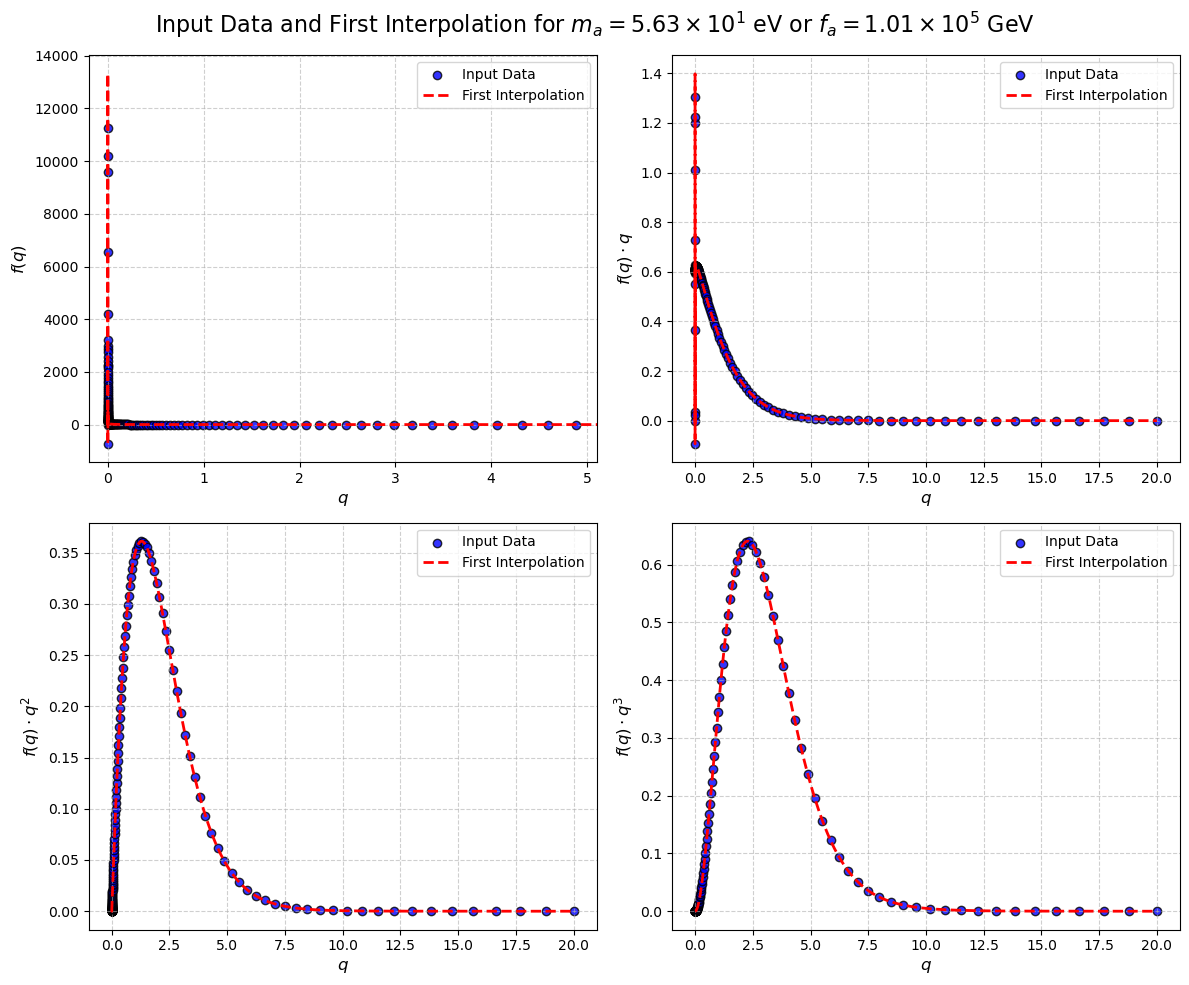

In [7]:
# Retrieve data
axion_mass = axionModelClass.get_axion_masses()[index]
decay_constant = axionModelClass.calculate_fa(axion_mass)
input_dist_q0 = axionModelClass.get_input_distribution(dist="f(q)")
input_dist_q1 = axionModelClass.get_input_distribution(dist="f(q)_q1")
input_dist_q2 = axionModelClass.get_input_distribution(dist="f(q)_q2")
input_dist_q3 = axionModelClass.get_input_distribution(dist="f(q)_q3")
input_q_arr = axionModelClass.get_comoving_momenta()

# Convert to scientific notation and extract base & exponent
axion_mass_base, axion_mass_exp = f"{axion_mass:.2e}".split("e")
decay_constant_base, decay_constant_exp = f"{decay_constant:.2e}".split("e")
# Format with integer exponents (ensuring proper LaTeX)
axion_mass_formatted = rf"{float(axion_mass_base):.2f} \times 10^{{{int(axion_mass_exp)}}}"
decay_constant_formatted = rf"{float(decay_constant_base):.2f} \times 10^{{{int(decay_constant_exp)}}}"

# First interpolation data
interp1_q_arr = np.logspace(np.log10(1e-4), np.log10(20), 500, base=10.0)
interp1_dist_q0 = axionModelClass.get_interpolated_distribution(dist="f(q)")
interp1_dist_q1 = axionModelClass.get_interpolated_distribution(dist="f(q)_q1")
interp1_dist_q2 = axionModelClass.get_interpolated_distribution(dist="f(q)_q2")
interp1_dist_q3 = axionModelClass.get_interpolated_distribution(dist="f(q)_q3")

# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(rf"Input Data and First Interpolation for $m_a = {axion_mass_formatted}$ eV or " 
             rf"$f_a = {decay_constant_formatted}$ GeV", fontsize=16)

# Define plot titles and datasets
titles = [r'$f(q)$', r'$f(q) \cdot q$', 
          r'$f(q) \cdot q^2$', r'$f(q) \cdot q^3$']
input_dists = [input_dist_q0, input_dist_q1, input_dist_q2, input_dist_q3]
interp_dists = [interp1_dist_q0, interp1_dist_q1, interp1_dist_q2, interp1_dist_q3]

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(input_q_arr, input_dists[i][index], 
               color='blue', marker='o', edgecolors='black', 
               alpha=0.8, label='Input Data')

    # Plot first interpolation
    ax.plot(interp1_q_arr, interp_dists[i][index](interp1_q_arr), 
            linestyle='--', linewidth=2, color='red', 
            label='First Interpolation')

    # Labels and title
    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    if i == 0:
        ax.set_xlim(left=-0.2,right=5.1)

# Adjust layout
plt.tight_layout()
plt.show()

## Checking Second Interpolation

In [8]:
# index of the distribution
index = index_main  # index of the distribution
# index = 250

/tmp/ipykernel_36215/2083898809.py:59: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(left=-0.2,right=5.1)


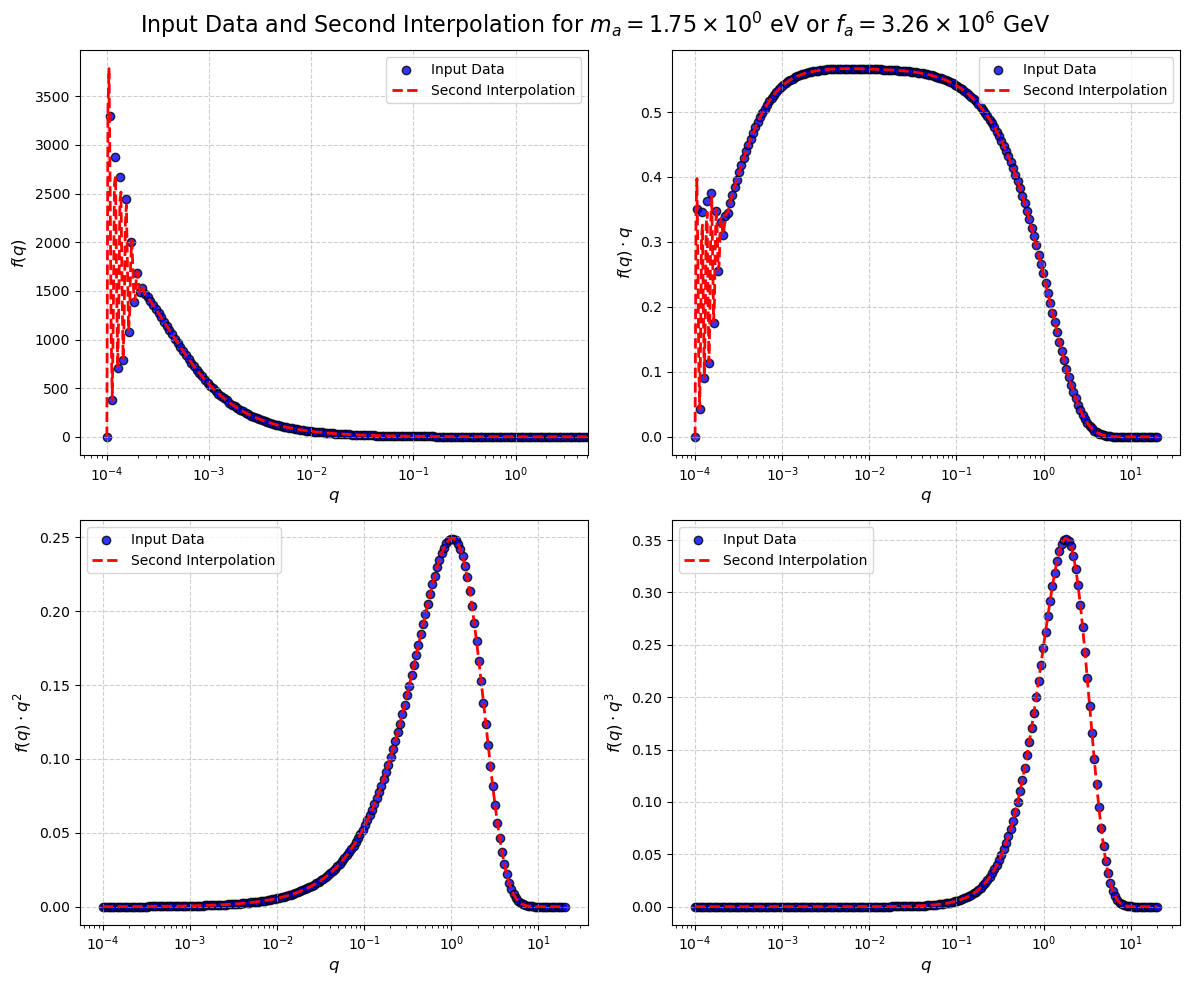

In [9]:
# Retrieve data
axion_mass = axionModelClass.get_axion_masses()[index]
decay_constant = axionModelClass.calculate_fa(axion_mass)
input_dist_q0 = axionModelClass.get_input_distribution(dist="f(q)")
input_dist_q1 = axionModelClass.get_input_distribution(dist="f(q)_q1")
input_dist_q2 = axionModelClass.get_input_distribution(dist="f(q)_q2")
input_dist_q3 = axionModelClass.get_input_distribution(dist="f(q)_q3")
input_q_arr = axionModelClass.get_comoving_momenta()

# Convert to scientific notation and extract base & exponent
axion_mass_base, axion_mass_exp = f"{axion_mass:.2e}".split("e")
decay_constant_base, decay_constant_exp = f"{decay_constant:.2e}".split("e")
# Format with integer exponents (ensuring proper LaTeX)
axion_mass_formatted = rf"{float(axion_mass_base):.2f} \times 10^{{{int(axion_mass_exp)}}}"
decay_constant_formatted = rf"{float(decay_constant_base):.2f} \times 10^{{{int(decay_constant_exp)}}}"

# --- SECOND INTERPOLATION
interp2_q_arr = np.logspace(np.log10(1e-4), np.log10(20), 500, base=10.0)
second_interpolation_q3 = axionModelClass.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q3")
second_interpolation_q2 = axionModelClass.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q2")
second_interpolation_q1 = axionModelClass.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)_q1")
second_interpolation_q0 = axionModelClass.generate_second_interpolation(axion_mass, interp2_q_arr, dist="f(q)")

# --- PLOT PART
# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(rf"Input Data and Second Interpolation for $m_a = {axion_mass_formatted}$ eV or " 
             rf"$f_a = {decay_constant_formatted}$ GeV", fontsize=16)

# Define plot titles and datasets
titles = [r'$f(q)$', r'$f(q) \cdot q$', 
          r'$f(q) \cdot q^2$', r'$f(q) \cdot q^3$']
input_dists = [input_dist_q0, input_dist_q1, input_dist_q2, input_dist_q3]
interp2_dists = [second_interpolation_q0, second_interpolation_q1, second_interpolation_q2, second_interpolation_q3]

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(input_q_arr, input_dists[i][index], 
               color='blue', marker='o', edgecolors='black', 
               alpha=0.8, label='Input Data')

    # Plot first interpolation
    ax.plot(interp1_q_arr, interp_dists[i][index](interp1_q_arr), 
            linestyle='--', linewidth=2, color='red', 
            label='Second Interpolation')

    # Labels and title
    ax.set_xlabel(r'$q$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    ax.set_xscale('log')


    if i == 0:
        ax.set_xlim(left=-0.2,right=5.1)

# Adjust layout
plt.tight_layout()
plt.show()